In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/resume-dataset/Resume/Resume.csv
/kaggle/input/resume-dataset/data/data/DESIGNER/22506245.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/13998435.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/67582956.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/34349255.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/26790545.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/12674307.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/11807040.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/44145704.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/27497542.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/11155153.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/17555081.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/41506705.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/54201930.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/24583187.pdf
/kaggle/input/resume-dataset/data/data/DESIGNER/38565119.pdf
/kaggle/input/resume-dataset/data/data

In [1]:
# ============================================
# AI-ASSISTED SMART RECRUITMENT SYSTEM - KAGGLE
# ============================================

# 1️⃣ Install Required Packages (CPU-only FAISS)
!pip install --quiet pdfplumber sentence-transformers faiss-cpu nltk spacy
!python -m spacy download en_core_web_sm

# 2️⃣ Import Libraries
import os
import pandas as pd
import numpy as np
import pdfplumber
import nltk
import torch
import faiss
import spacy

from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder

nltk.download('stopwords')

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# 3️⃣ Load Resume CSV (Optional: for labels or metadata)
csv_path = "/kaggle/input/resume-dataset/Resume/Resume.csv"
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print("Resume CSV loaded. Columns:", df.columns)
else:
    print("CSV file not found, will proceed with PDFs only.")

# 4️⃣ Define Paths for PDFs
BASE_PATH = "/kaggle/input/resume-dataset/data/data"

# 5️⃣ Extract Text from PDF Resumes
def extract_pdf_text(pdf_path):
    text = ""
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + " "
    except Exception as e:
        print(f"Failed to read {pdf_path}: {e}")
    return text

resume_texts = []
resume_labels = []

for category in os.listdir(BASE_PATH):
    category_path = os.path.join(BASE_PATH, category)
    if os.path.isdir(category_path):
        for file in os.listdir(category_path):
            if file.endswith(".pdf"):
                pdf_path = os.path.join(category_path, file)
                text = extract_pdf_text(pdf_path)
                if len(text) > 50:
                    resume_texts.append(text)
                    resume_labels.append(category)

print(f"Total resumes processed: {len(resume_texts)}")

# 6️⃣ Encode Resume Categories
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(resume_labels)

# 7️⃣ Load Sentence-BERT Model (GPU if available)
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

# 8️⃣ Generate Resume Embeddings
resume_embeddings = model.encode(resume_texts, batch_size=32, show_progress_bar=True, convert_to_numpy=True)

# 9️⃣ Build FAISS Index (CPU-compatible)
dimension = resume_embeddings.shape[1]
index = faiss.IndexFlatL2(dimension)
index.add(resume_embeddings)  # no GPU required

# 10️⃣ Job Description Input
job_description = """
We are looking for a UI/UX Designer with experience in Figma,
Adobe XD, wireframing, prototyping, and responsive web design.
Strong communication skills and portfolio required.
"""

# 11️⃣ Encode Job Description
job_embedding = model.encode([job_description], convert_to_numpy=True)

# 12️⃣ Search Top K Matching Candidates
TOP_K = 5
distances, indices = index.search(job_embedding, TOP_K)

# 13️⃣ Display Ranked Candidates
print("🔹 TOP MATCHING CANDIDATES 🔹\n")
for rank, idx in enumerate(indices[0]):
    print(f"Rank {rank+1}")
    print("Category:", resume_labels[idx])
    print("Similarity Score:", round(1 / (1 + distances[0][rank]), 3))
    print("-" * 50)

# 14️⃣ Optional: Simple Skill Extraction
nlp = spacy.load("en_core_web_sm")

def extract_skills(text, top_n=15):
    doc = nlp(text.lower())
    skills = set()
    for token in doc:
        if token.pos_ in ["NOUN", "PROPN"]:
            skills.add(token.text)
    return list(skills)[:top_n]

# Example: extract skills from top candidate
print("Skills from top candidate:", extract_skills(resume_texts[indices[0][0]]))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 98.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 86.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 83.8 MB/s eta 0:00:00:00:01
/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 80.4 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies.

2026-01-02 09:38:17.414268: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767346697.594745      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767346697.648964      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767346698.097663      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767346698.097698      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767346698.097701      55 computation_placer.cc:177] computation placer alr

Device: cuda
Resume CSV loaded. Columns: Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')
Total resumes processed: 2483


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/78 [00:00<?, ?it/s]

🔹 TOP MATCHING CANDIDATES 🔹

Rank 1
Category: DESIGNER
Similarity Score: 0.612
--------------------------------------------------
Rank 2
Category: DESIGNER
Similarity Score: 0.596
--------------------------------------------------
Rank 3
Category: DESIGNER
Similarity Score: 0.587
--------------------------------------------------
Rank 4
Category: DESIGNER
Similarity Score: 0.584
--------------------------------------------------
Rank 5
Category: DESIGNER
Similarity Score: 0.565
--------------------------------------------------
Skills from top candidate: ['requisition', 'initiative', 'charcoals', 'artwork', 'translator', 'covers', 'shops', 'interests', '3d', 'f828', 'jan', '12/2006', 'illustration', 'employee', 'operating']


In [3]:
# ============================================
# EXTENDED SMART RECRUITMENT SYSTEM (FIXED)
# Resume Classification | Skill Gap | Hire Probability
# ============================================

import numpy as np
import spacy
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity  # ✅ FIX

# -----------------------------
# 1️⃣ RESUME CLASSIFICATION
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    resume_embeddings,
    encoded_labels,
    test_size=0.2,
    random_state=42,
    stratify=encoded_labels
)

clf = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    n_jobs=-1
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("✅ RESUME CLASSIFICATION REPORT")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))


# -----------------------------
# 2️⃣ SKILL-GAP DETECTION
# -----------------------------
nlp = spacy.load("en_core_web_sm")

def extract_skills(text, top_n=30):
    doc = nlp(text.lower())
    skills = set()
    for token in doc:
        if token.pos_ in ["NOUN", "PROPN"] and len(token.text) > 2:
            skills.add(token.text)
    return list(skills)[:top_n]

# Example job-required skills
job_skills = [
    "figma", "adobe", "wireframing",
    "prototyping", "responsive", "communication"
]

print("\n🔹 SKILL GAP ANALYSIS 🔹")
for rank, idx in enumerate(indices[0]):
    candidate_skills = extract_skills(resume_texts[idx])
    missing_skills = list(set(job_skills) - set(candidate_skills))

    print(f"Rank {rank+1} | Category: {resume_labels[idx]}")
    print("Matched Skills:", list(set(candidate_skills) & set(job_skills)))
    print("Missing Skills:", missing_skills)
    print("-" * 50)


# -----------------------------
# 3️⃣ HIRE PROBABILITY PREDICTION
# -----------------------------
def hire_probability(resume_idx, job_embedding, job_skills):
    # Semantic similarity
    resume_emb = resume_embeddings[resume_idx].reshape(1, -1)
    similarity = cosine_similarity(resume_emb, job_embedding)[0][0]

    # Skill coverage
    candidate_skills = extract_skills(resume_texts[resume_idx])
    skill_coverage = len(set(candidate_skills) & set(job_skills)) / len(job_skills)

    # Weighted hiring probability
    probability = (0.65 * similarity) + (0.35 * skill_coverage)
    return round(probability, 3)


print("\n🔹 HIRE PROBABILITY SCORES 🔹")
for rank, idx in enumerate(indices[0]):
    prob = hire_probability(idx, job_embedding, job_skills)
    print(
        f"Rank {rank+1} | "
        f"Category: {resume_labels[idx]} | "
        f"Hire Probability: {prob}"
    )


✅ RESUME CLASSIFICATION REPORT
                        precision    recall  f1-score   support

            ACCOUNTANT       0.74      0.96      0.84        24
              ADVOCATE       0.60      0.62      0.61        24
           AGRICULTURE       1.00      0.15      0.27        13
               APPAREL       0.43      0.16      0.23        19
                  ARTS       0.25      0.05      0.08        21
            AUTOMOBILE       1.00      0.14      0.25         7
              AVIATION       0.57      0.50      0.53        24
               BANKING       0.44      0.35      0.39        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.68      0.71      0.69        24
                  CHEF       0.79      0.92      0.85        24
          CONSTRUCTION       0.76      0.86      0.81        22
            CONSULTANT       0.56      0.39      0.46        23
              DESIGNER       0.71      0.71      0.71        21
        

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



🔹 SKILL GAP ANALYSIS 🔹
Rank 1 | Category: DESIGNER
Matched Skills: ['communication']
Missing Skills: ['adobe', 'wireframing', 'responsive', 'figma', 'prototyping']
--------------------------------------------------
Rank 2 | Category: DESIGNER
Matched Skills: []
Missing Skills: ['adobe', 'wireframing', 'responsive', 'communication', 'figma', 'prototyping']
--------------------------------------------------
Rank 3 | Category: DESIGNER
Matched Skills: []
Missing Skills: ['adobe', 'wireframing', 'responsive', 'communication', 'figma', 'prototyping']
--------------------------------------------------
Rank 4 | Category: DESIGNER
Matched Skills: ['communication']
Missing Skills: ['adobe', 'wireframing', 'responsive', 'figma', 'prototyping']
--------------------------------------------------
Rank 5 | Category: DESIGNER
Matched Skills: []
Missing Skills: ['adobe', 'wireframing', 'responsive', 'communication', 'figma', 'prototyping']
--------------------------------------------------

🔹 HIRE PR

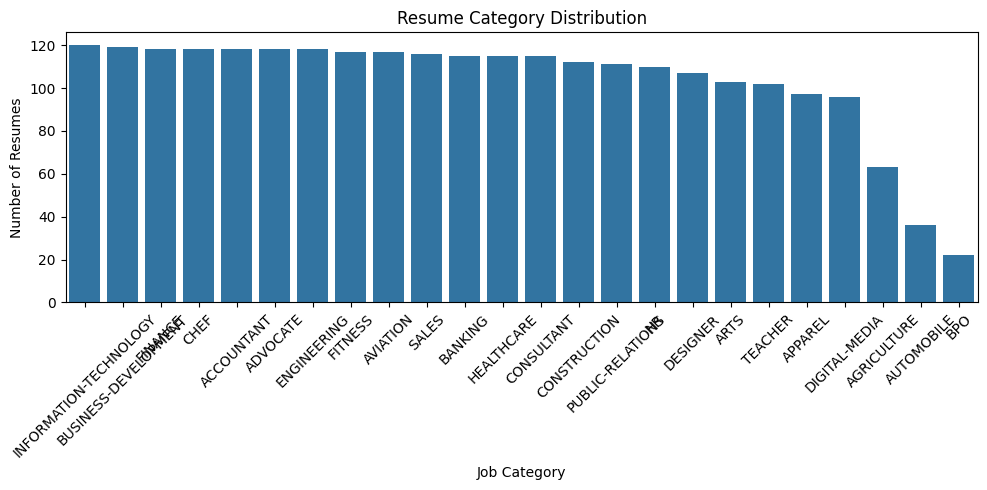

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.countplot(x=resume_labels, order=pd.Series(resume_labels).value_counts().index)
plt.xticks(rotation=45)
plt.title("Resume Category Distribution")
plt.xlabel("Job Category")
plt.ylabel("Number of Resumes")
plt.tight_layout()
plt.show()


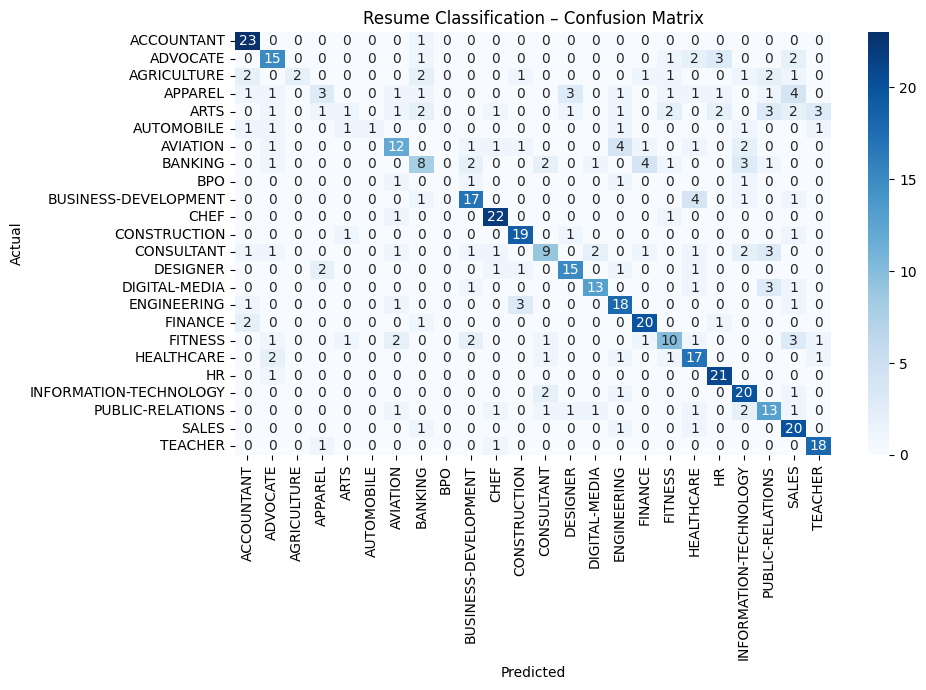

In [5]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title("Resume Classification – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


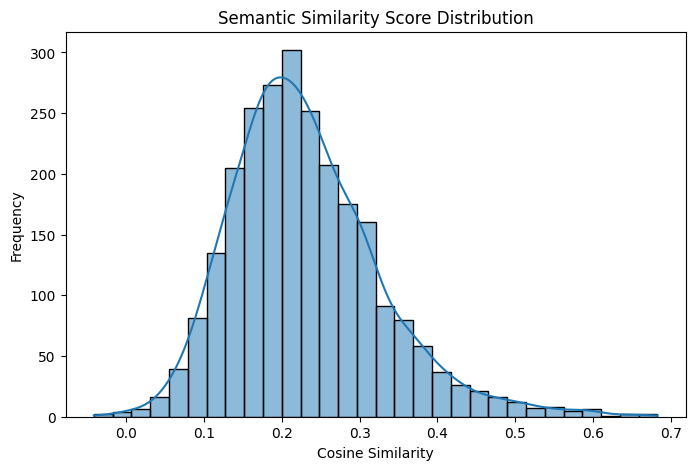

In [6]:
similarity_scores = []

for i in range(len(resume_embeddings)):
    sim = cosine_similarity(
        resume_embeddings[i].reshape(1, -1),
        job_embedding
    )[0][0]
    similarity_scores.append(sim)

plt.figure(figsize=(8,5))
sns.histplot(similarity_scores, bins=30, kde=True)
plt.title("Semantic Similarity Score Distribution")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.show()


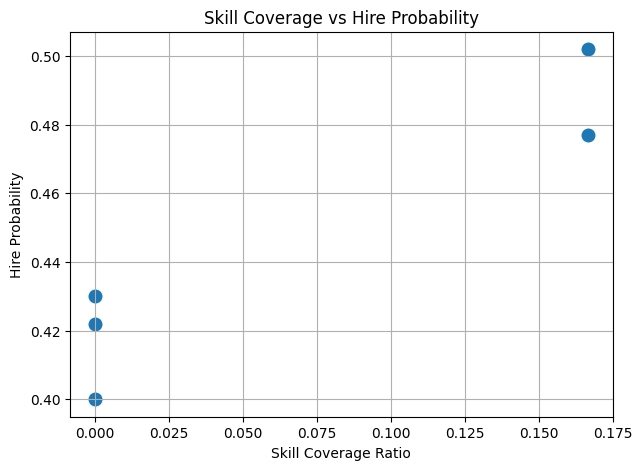

In [7]:
skill_coverages = []
hire_probs = []

for i in indices[0]:
    candidate_skills = extract_skills(resume_texts[i])
    coverage = len(set(candidate_skills) & set(job_skills)) / len(job_skills)
    skill_coverages.append(coverage)
    hire_probs.append(hire_probability(i, job_embedding, job_skills))

plt.figure(figsize=(7,5))
sns.scatterplot(
    x=skill_coverages,
    y=hire_probs,
    s=120
)
plt.title("Skill Coverage vs Hire Probability")
plt.xlabel("Skill Coverage Ratio")
plt.ylabel("Hire Probability")
plt.grid(True)
plt.show()


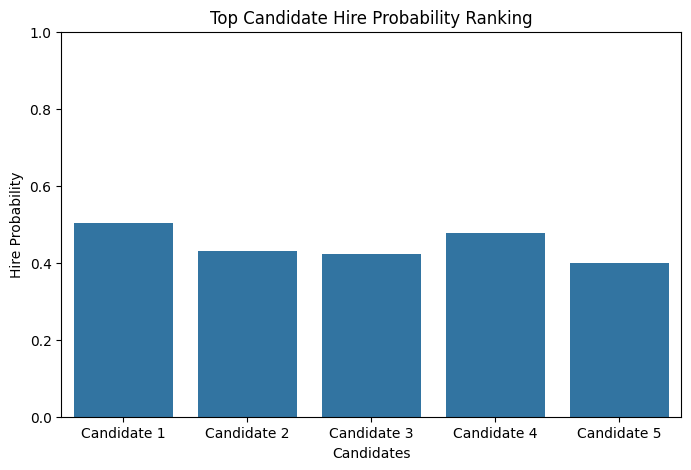

In [8]:
candidate_names = [f"Candidate {i+1}" for i in range(len(indices[0]))]
candidate_probs = [hire_probability(i, job_embedding, job_skills) for i in indices[0]]

plt.figure(figsize=(8,5))
sns.barplot(x=candidate_names, y=candidate_probs)
plt.title("Top Candidate Hire Probability Ranking")
plt.xlabel("Candidates")
plt.ylabel("Hire Probability")
plt.ylim(0, 1)
plt.show()


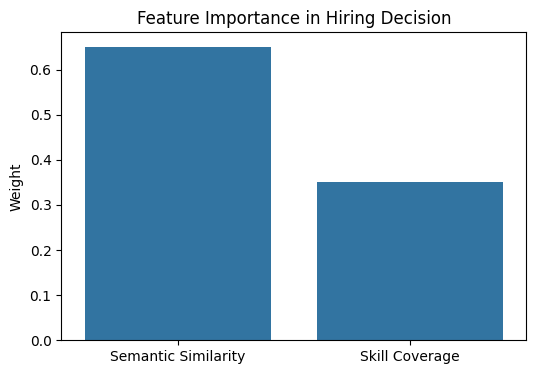

In [9]:
features = ["Semantic Similarity", "Skill Coverage"]
importance = [0.65, 0.35]  # weights used in hire_probability

plt.figure(figsize=(6,4))
sns.barplot(x=features, y=importance)
plt.title("Feature Importance in Hiring Decision")
plt.ylabel("Weight")
plt.show()


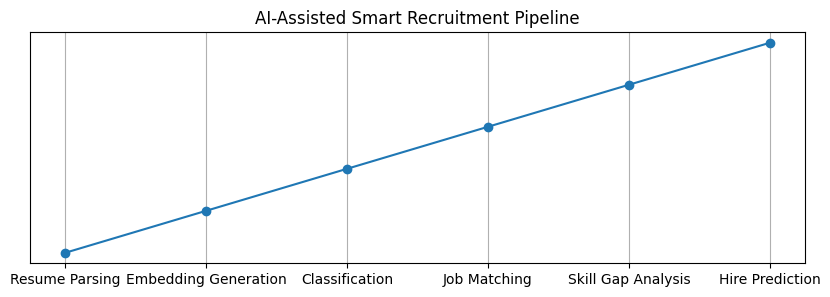

In [10]:
stages = [
    "Resume Parsing",
    "Embedding Generation",
    "Classification",
    "Job Matching",
    "Skill Gap Analysis",
    "Hire Prediction"
]

plt.figure(figsize=(10,3))
plt.plot(stages, range(len(stages)), marker="o")
plt.yticks([])
plt.title("AI-Assisted Smart Recruitment Pipeline")
plt.grid(True)
plt.show()
